# Face Cutout and Chin Masking
This notebook isolates a person from the background and applies a perfectly curated, organic chin mask.

In [ ]:
import cv2
import numpy as np
import torch
from PIL import Image
from transformers import SegformerImageProcessor, SegformerForSemanticSegmentation
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision
from scipy.interpolate import splprep, splev
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output
import io

In [ ]:
# Initialize SegFormer
print("Loading SegFormer model...")
processor = SegformerImageProcessor.from_pretrained("jonathandinu/face-parsing")
model = SegformerForSemanticSegmentation.from_pretrained("jonathandinu/face-parsing")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
print("SegFormer ready!")

Loading SegFormer model...


Loading weights:   0%|          | 0/1172 [00:00<?, ?it/s]

SegFormer ready!


In [ ]:
# Initialize MediaPipe Face Landmarker
print("Loading MediaPipe model...")
fm_model_path = 'face_landmarker.task'
fm_base_options = python.BaseOptions(model_asset_path=fm_model_path)
fm_options = vision.FaceLandmarkerOptions(base_options=fm_base_options,
                                       output_face_blendshapes=False,
                                       output_facial_transformation_matrixes=False,
                                       num_faces=1)
landmarker = vision.FaceLandmarker.create_from_options(fm_options)
print("MediaPipe ready!")

Loading MediaPipe model...
MediaPipe ready!


In [ ]:
import tkinter as tk
from tkinter import filedialog

print("Opening file dialog... Please check your taskbar for the popup window.")

root = tk.Tk()
root.attributes('-topmost', True) # Bring to front
root.withdraw() # Hide the main tk window

file_path = filedialog.askopenfilename(
    title="Select an Image",
    filetypes=[("Image files", "*.jpg *.jpeg *.png *.bmp")]
)

root.destroy()

if file_path:
    print(f"Selected file: {file_path}")
    print("You can now run the next cell!")
else:
    print("No file selected. We will use the sample image.")


Opening file dialog... Please check your taskbar for the popup window.
Selected file: C:/Users/PratikJPatel/Downloads/360_F_326625213_uHDip2WjaMsEfKpImZ5MDDlrobu2Ui0E.jpg
You can now run the next cell!


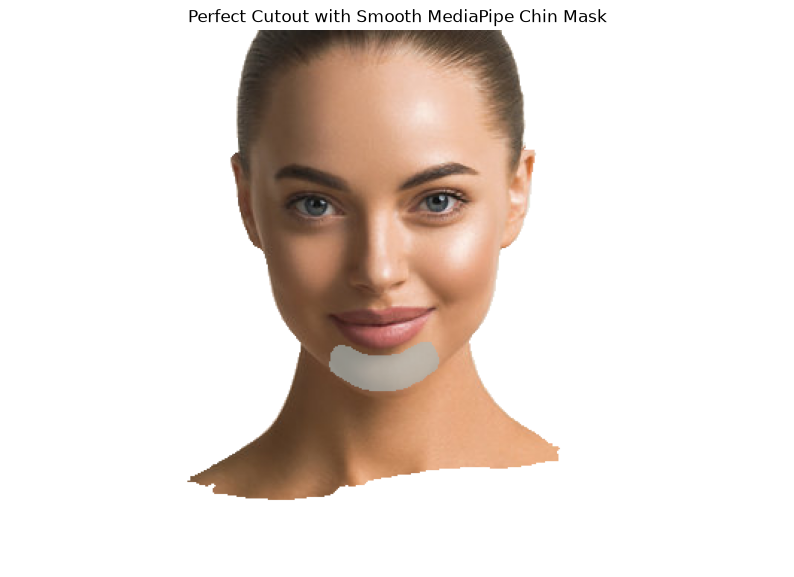

In [ ]:
import os
import urllib.request

if file_path:
    image = cv2.imread(file_path)
else:
    print("No image uploaded. Using sample image.")
    IMAGE_PATH = 'sample_face.jpg'
    if not os.path.exists(IMAGE_PATH):
        req = urllib.request.Request('https://upload.wikimedia.org/wikipedia/commons/thumb/a/a0/Pierre-Person.jpg/800px-Pierre-Person.jpg', headers={'User-Agent': 'Mozilla/5.0'})
        with urllib.request.urlopen(req) as response, open(IMAGE_PATH, 'wb') as out_file:
            out_file.write(response.read())
    image = cv2.imread(IMAGE_PATH)

if image is not None:
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    h, w, _ = image_rgb.shape
    
    # --- 1. Background Removal (SegFormer) ---
    pil_image = Image.fromarray(image_rgb)
    inputs = processor(images=pil_image, return_tensors="pt").to(device)
    with torch.no_grad():
        outputs = model(**inputs)
    logits = outputs.logits
    upsampled = torch.nn.functional.interpolate(
        logits, size=pil_image.size[::-1], mode="bilinear", align_corners=False
    )
    labels = upsampled.argmax(dim=1)[0].cpu().numpy()
    
    face_mask = np.isin(labels, list(range(1, 18)))
    bg_image = np.ones_like(image_rgb) * 255
    cutout_image = np.where(face_mask[..., None], image_rgb, bg_image)
    
    # --- 2. Draw Chin Overlay (MediaPipe) ---
    mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=image_rgb)
    detection_result = landmarker.detect(mp_image)
    final_image = cutout_image.copy()
    
    if detection_result.face_landmarks:
        landmarks = detection_result.face_landmarks[0]
        
        # Perfect crescent shape mathematically curated from the mesh
        CHIN_INDICES = [204, 83, 18, 313, 424, 431, 395, 369, 396, 175, 171, 140, 170, 211]
        
        # Use Scipy to apply organic smoothing to the polygon
        def get_smooth_polygon(indices):
            pts = np.array([[landmarks[idx].x * w, landmarks[idx].y * h] for idx in indices])
            pts = np.vstack((pts, pts[0])) # close loop
            
            tck, u = splprep([pts[:,0], pts[:,1]], s=0, per=True)
            unew = np.linspace(0, 1.0, 100)
            out = splev(unew, tck)
            
            smooth_pts = np.vstack((out[0], out[1])).T
            return np.int32(smooth_pts)

        chin_pts = get_smooth_polygon(CHIN_INDICES)
        
        overlay = final_image.copy()
        CHIN_COLOR = (170, 185, 185) # Slightly different pastel color
        
        cv2.fillPoly(overlay, [chin_pts], CHIN_COLOR)
        
        alpha = 0.65
        final_image = cv2.addWeighted(overlay, alpha, final_image, 1 - alpha, 0)
    else:
        print("No face detected for landmarking.")
    
    plt.figure(figsize=(10, 10))
    plt.imshow(final_image)
    plt.axis('off')
    plt.title("Perfect Cutout with Smooth MediaPipe Chin Mask")
    plt.show()
